# **Ensemble Model Training**

## **Cell 1 - Installation**

### Cell 1: Install Required Python Libraries

## Objective
Install all the required Python libraries needed for data preprocessing, machine learning, text processing, and model development.

## Purpose
This step ensures that all external packages required by the project are available in the notebook before executing the remaining code cells.

## Expected Output
The required libraries are installed successfully without displaying unnecessary installation logs.

### Why is this step required?
### The Toxic Comment Classification project depends on several third-party libraries. Installing them at the beginning prevents import errors in later stages of the notebook.

In [1]:
!pip install scikit-learn pandas numpy fuzzywuzzy python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.4 MB/s eta 0:00:00


## **Cell 2 - Import Libraries and Dependencies**

# Cell 2: Import Required Libraries and Dependencies

## Objective
Import all the Python libraries required for data manipulation, text preprocessing, machine learning, model evaluation, file handling, and warning management.

## Purpose
These libraries provide the necessary functions and classes for loading the dataset, preprocessing text, extracting TF-IDF features, training the ensemble model, evaluating model performance, and saving the trained model.

## Expected Output
All required libraries are imported successfully and are available for use throughout the notebook without any import errors.

## Why is this step required?
Every stage of the Toxic Comment Classification pipeline depends on these libraries. Importing them at the beginning ensures that all required modules are available before executing the remaining cells.

In [2]:
import pandas as pd    # Import the Pandas library and assign the alias 'pd'.
# Used for loading, manipulating, cleaning, and analyzing tabular datasets.
import numpy as np  # Import the NumPy library and assign the alias 'np'.
# Used for numerical computations, mathematical operations, and array manipulation.
import re  # Import the Regular Expression (re) module.
# Used for text preprocessing such as removing unwanted characters and pattern matching.
import pickle   # Import the Pickle module.
# Used to save (serialize) and load (deserialize) trained machine learning models and objects.
import os  # Import the OS module.
# Used to perform file and directory operations such as creating folders and checking file paths.
import time  # Import the Time module.
# Used to measure the training and inference time of the machine learning model.
from fuzzywuzzy import fuzz  # Import the fuzz module from the FuzzyWuzzy library.
# Used to perform fuzzy string matching for detecting similar or obfuscated words.
from sklearn.model_selection import train_test_split  # Import train_test_split.
# Used to divide the dataset into training and testing datasets for model evaluation.
from sklearn.feature_extraction.text import TfidfVectorizer  # Import the TF-IDF Vectorizer.
# Converts text comments into numerical feature vectors that machine learning models can understand.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
# Import ensemble learning algorithms.
# RandomForestClassifier is used as one of the base classifiers.
# GradientBoostingClassifier can be used as another ensemble model (optional).
# VotingClassifier combines multiple classifiers to improve prediction performance.
from sklearn.linear_model import LogisticRegression  # Import Logistic Regression.
# Used as one of the base classifiers in the ensemble model.
from sklearn.multioutput import MultiOutputClassifier  # Import MultiOutputClassifier.
# Enables a single classifier to predict multiple toxicity labels simultaneously.
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)         # Import evaluation metrics.
# accuracy_score    : Measures overall prediction accuracy.
# precision_score   : Measures the proportion of correct positive predictions.
# recall_score      : Measures how many actual positive samples are correctly identified.
# f1_score          : Computes the harmonic mean of precision and recall.
import warnings   # Import the warnings module.
# Used to control and manage warning messages generated during code execution.
warnings.filterwarnings('ignore')    # Ignore all warning messages.
# Keeps the notebook output clean and focused on the important results.


## **Cell 3 - Defining TextProcessor Class**

# Cell 3: Define the Text Processing Class

## Objective
Create a reusable text preprocessing class that cleans and normalizes toxic comments before they are converted into numerical features for model training and prediction.

## Purpose
The `TextProcessor` class standardizes text by removing obfuscation, repeated characters, unnecessary spaces, and special symbols. This helps improve the quality of the input data and enables the machine learning model to learn meaningful patterns.

## Expected Output
A `TextProcessor` object capable of transforming raw user comments into clean and normalized text suitable for TF-IDF feature extraction and toxicity classification.

## Why is this step required?
User-generated comments often contain spelling variations, repeated characters, symbols, and intentionally obfuscated words to bypass moderation systems. Cleaning and normalizing the text improves feature consistency and helps the model achieve better prediction accuracy.

In [3]:
# Used to process text before training and prediction
# Handles obfuscation, repeated characters, and special characters

# Define a class named TextProcessor.
# This class groups together all text preprocessing methods into a single reusable object.
class TextProcessor:


  # Constructor method that automatically runs when an object of the class is created.
    # It initializes variables and configuration settings required by the class.
    def __init__(self):

      # Create a dictionary that maps commonly obfuscated characters
        # back to their original alphabetic characters.
        # This helps detect words intentionally modified to avoid moderation.
        self.obfuscation_map = {
            '0': 'o', '1': 'i', '3': 'e', '4': 'a',
            '5': 's', '7': 't', '@': 'a', '$': 's',
            '+': 't', '8': 'b'
        }

    # Define a function to replace obfuscated characters in the text.

    def remove_obfuscation(self, text):


         # Iterate through every character in the text.
        # Replace characters using the dictionary if available.
        # Otherwise, keep the original character unchanged

        return ''.join(self.obfuscation_map.get(c, c) for c in text)


     # Static method because it does not require access to object variables.

    @staticmethod
    # Remove characters repeated more than twice.
    # Example:
    # "stuuuuupid" → "stupid"
    def collapse_repeated_chars(text):

       # Regular expression replaces three or more repeated characters
        # with a single occurrence.
        return re.sub(r'(.)\1{2,}', r'\1', text)

        # Static method for removing unnecessary spaces between letters.

    @staticmethod

     # Example:
    # "h e l l o" → "hello"
    def remove_spaced_letters(text):

      # Regular expression joins letters separated by spaces.
        return re.sub(r'(?<!\w)(\w)\s+(?=(\w\s)*\w(?!\w))', r'\1', text)


         # Static method for removing special characters.

    @staticmethod


    # Removes punctuation and symbols while preserving
    # lowercase letters, numbers, and spaces.
    def clean_special_chars(text):

      # Keep only letters, digits, and whitespace.
        return re.sub(r'[^a-z0-9\s]', '', text)

         # Main preprocessing function that performs all cleaning steps.

    def normalize(self, text):

      # Check whether the input is a string.
        # If not, return an empty string to avoid runtime errors.
        if not isinstance(text, str):
            return ""
        steps = [
            str.lower,
            self.remove_obfuscation,
            self.collapse_repeated_chars,
            self.remove_spaced_letters,
            self.clean_special_chars,
            lambda t: re.sub(r'\s+', ' ', t).strip()
        ]
        for step in steps:
            text = step(text)
        return text

    def process_text(self, text):
        return  self.normalize(text)

        # Create an object of the TextProcessor class.
# This object will be used later to preprocess all comments
# before TF-IDF feature extraction and model prediction.

tp = TextProcessor()

## **Cell 4 - Load Dataset**

# Cell 4: Load the Dataset and Analyze Label Distribution

## Objective
Load the balanced training dataset into a Pandas DataFrame and analyze the distribution of toxicity labels before training the machine learning model.

## Purpose
This step verifies that the dataset has been loaded correctly and provides an overview of the number of samples in each toxicity category. Understanding the label distribution helps identify class imbalance and ensures that the dataset is suitable for training.

## Expected Output
- The balanced dataset is successfully loaded into memory.
- The shape of the dataset (rows and columns) is displayed.
- The number and percentage of samples belonging to each toxicity label are displayed.
- The overall number of toxic and non-toxic (clean) comments is displayed.

## Why is this step required?
Before training a machine learning model, it is important to verify the dataset and understand its class distribution. This helps detect data loading issues, identify class imbalance, and confirms that the target labels are available for multi-label toxicity classification.

In [4]:
df = pd.read_csv('/content/train_balanced.csv') # Read the balanced training dataset from the CSV file.
# The dataset contains user comments and their corresponding toxicity labels.


# Create a list containing the names of all target labels.
# These labels represent the six toxicity categories that the model will predict.

label_cols = ['toxic', 'severe_toxic', 'obscene',
              'threat', 'insult', 'identity_hate']

# Calculate the total number of comments in the dataset.
# This value is used to compute percentages later.

total       = len(df)
toxic_count = (df[label_cols].sum(axis=1) > 0).sum()
clean_count = (df[label_cols].sum(axis=1) == 0).sum()


# Display the number of rows and columns in the dataset.
# This confirms that the dataset has been loaded successfully.
print(f"Dataset shape : {df.shape}")
print(f"\n========== Label Distribution ==========")
for col in label_cols:
    count   = df[col].sum()
    percent = (count / len(df)) * 100
    print(f"  {col:15s}: {count:6d} ({percent:.2f}%)")

print(f"\n========== Overall Distribution ==========")
print(f"  Total   : {total:,}")
print(f"  Toxic   : {toxic_count:,}  ({toxic_count/total*100:.2f}%)")
print(f"  Clean   : {clean_count:,} ({clean_count/total*100:.2f}%)")

Dataset shape : (216237, 8)

========== Label Distribution ==========
  toxic          :  69179 (31.99%)
  severe_toxic   :  24225 (11.20%)
  obscene        :  53661 (24.82%)
  threat         :  17753 (8.21%)
  insult         :  53172 (24.59%)
  identity_hate  :  22947 (10.61%)

========== Overall Distribution ==========
  Total   : 216,237
  Toxic   : 72,891  (33.71%)
  Clean   : 143,346 (66.29%)


## **Cell 5 - Process and Balance Dataset**

# Cell 5: Text Preprocessing, Dataset Balancing, and Train-Test Split

## Objective
Clean the raw comments, balance the dataset by reducing the number of clean comments, and split the dataset into training and testing sets for model development.

## Purpose
This step prepares the dataset for machine learning by removing inconsistencies in the text, reducing class imbalance, and separating the data into training and testing subsets.

## Expected Output
- A new column containing cleaned comments.
- A balanced dataset with a better ratio of toxic and clean comments.
- Training and testing datasets ready for TF-IDF feature extraction and model training.
- A summary showing the number of samples in each dataset.

## Why is this step required?
Machine learning models perform better when trained on clean and balanced data. Preprocessing improves text quality, balancing reduces bias toward the majority class, and train-test splitting allows the model to be evaluated on unseen data.

In [5]:
# Apply text processing to all comment texts
df['clean_text'] = df['comment_text'].apply(tp.process_text)

# Balancing data set because it's is too imbalanced
# Separate toxic and clean
toxic_df = df[df[label_cols].sum(axis=1) > 0]
clean_df = df[df[label_cols].sum(axis=1) == 0]
clean_sampled = clean_df.sample(n=40000, random_state=67)

# Combine and shuffle
balanced_df = pd.concat([toxic_df, clean_sampled]).sample(
    frac=1, random_state=67
).reset_index(drop=True)

print(f"\nAfter balancing:")
print(f"  Total : {len(balanced_df)}")
print(f"  Toxic : {(balanced_df[label_cols].sum(axis=1) > 0).sum()}")
print(f"  Clean : {(balanced_df[label_cols].sum(axis=1) == 0).sum()}")

X = balanced_df['clean_text'].values
y = balanced_df[label_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


After balancing:
  Total : 112891
  Toxic : 72891
  Clean : 40000

Training samples : 90312
Testing samples  : 22579


## **Cell 6 - TF-IDF Transformation**

# Cell 6: TF-IDF Feature Extraction

## Objective
Convert the cleaned text comments into numerical feature vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique.

## Purpose
Machine learning algorithms cannot process raw text directly. TF-IDF transforms textual data into numerical representations by assigning higher importance to meaningful words and lower importance to very common words.

## Expected Output
- A trained TF-IDF vectorizer based on the training dataset.
- A sparse feature matrix for the training dataset.
- A transformed feature matrix for the testing dataset.
- The dimensions of both feature matrices.

## Why is this step required?
TF-IDF is a feature extraction technique that converts text into machine-readable numerical vectors while preserving the importance of words. Using the same TF-IDF vocabulary for both training and testing datasets ensures consistency and prevents data leakage.

In [6]:
# Convert text into TF-IDF features for toxicity classification
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

# Learn the TF-IDF vocabulary from the training dataset.
# At the same time, convert the training comments into TF-IDF feature vectors.
# The vectorizer must always be fitted using only the training data
# to prevent data leakage.
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the testing dataset using the vocabulary learned
# from the training dataset.
# Only transform() is used because the testing data should never
# influence the learned vocabulary.
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training matrix : {X_train_tfidf.shape}")
print(f"Testing matrix  : {X_test_tfidf.shape}")

Training matrix : (90312, 50000)
Testing matrix  : (22579, 50000)


## **Cell 7 - Training Ensemble Model**

# Cell 7: Train the Ensemble Machine Learning Model

## Objective
Build and train an ensemble machine learning model that combines multiple classifiers to perform multi-label toxicity classification.

## Purpose
This step creates two base machine learning models—Logistic Regression and Random Forest—and combines them using a Voting Classifier. The ensemble model is then wrapped inside a `MultiOutputClassifier` to predict multiple toxicity labels simultaneously.

## Expected Output
- A trained ensemble model capable of predicting all six toxicity labels.
- The total training time required to build the model.

## Why is this step required?
Different machine learning algorithms have different strengths. Combining multiple classifiers often produces more robust and accurate predictions than using a single model. The `MultiOutputClassifier` allows the ensemble model to predict multiple toxicity categories (e.g., Toxic, Threat, Insult) for the same comment.

In [7]:
# Define base classifiers
# Create a Logistic Regression classifier.
# Logistic Regression is a linear model that performs well on
# high-dimensional sparse data such as TF-IDF feature vectors.
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    random_state=42
)


# Create a Random Forest classifier.
# Random Forest is an ensemble learning algorithm that combines
# multiple decision trees to improve prediction accuracy.
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Voting Classifier (Ensemble)
# Using soft voting = uses probabilities, more accurate
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
    ],
    voting='soft',
    n_jobs=-1
)

# Wrap in MultiOutputClassifier for multi-label support
multi_ensemble = MultiOutputClassifier(ensemble, n_jobs=-1)

# Train
start_time = time.time()
multi_ensemble.fit(X_train_tfidf, y_train)
end_time = time.time()

print(f"Training time: {(end_time - start_time):.2f} seconds")

Training time: 6160.46 seconds


# 8 Evaluation on Training Data

---



Cell 8: Evaluate the Ensemble Model on the Training Dataset
Objective
Evaluate the performance of the trained ensemble model using the training dataset by calculating class-wise and overall evaluation metrics.

Purpose
This step measures how well the model has learned the training data. It computes performance metrics such as Accuracy, Precision, Recall, F1-Score, Confidence Level, and Inference Time for each toxicity category.

Expected Output
Predictions for every training sample.
Class-wise evaluation metrics for all six toxicity labels.
Overall model performance metrics.
Average confidence score.
Total inference time and average prediction time per sample.
Why is this step required?
Evaluating the model on the training dataset helps determine whether it has successfully learned the underlying patterns. Comparing these results with the testing evaluation later helps identify whether the model is underfitting or overfitting.

In [9]:
# Record the starting time before generating predictions.
# This is used to calculate the inference time of the model.


start = time.time()
y_pred_train = multi_ensemble.predict(X_train_tfidf)
y_pred_proba_train = np.array([
    est.predict_proba(X_train_tfidf)
    for est in multi_ensemble.estimators_
])
end = time.time()
inference_time_train = end - start

print("=" * 75)
print(f"{'ENSEMBLE MODEL TRAINING EVALUATION':^75}")
print("=" * 75)

results_train = []

# Create an empty list to store the evaluation results.
# Loop through each toxicity label.
for i, label in enumerate(label_cols):
    acc = accuracy_score(y_train[:, i], y_pred_train[:, i])
    prec = precision_score(y_train[:, i], y_pred_train[:, i], zero_division=0)
    rec = recall_score(y_train[:, i], y_pred_train[:, i], zero_division=0)
    f1 = f1_score(y_train[:, i], y_pred_train[:, i], zero_division=0)

    label_proba = y_pred_proba_train[i]
    if label_proba.shape[1] == 2:
        max_probas = np.max(label_proba, axis=1)
    else:
        max_probas = label_proba[:, 0]
    confidence = np.mean(max_probas)

    results_train.append({
        'Label': label,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1 Score': f"{f1:.4f}",
        'Confidence': f"{confidence:.4f}"
    })

# Display Class-wise Results

# Convert the results list into a Pandas DataFrame
results_df_train = pd.DataFrame(results_train)
print(results_df_train.to_string(index=False))

# Calculate Overall Performance Metrics

avg_acc_train = accuracy_score(y_train, y_pred_train)
avg_prec_train = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
avg_rec_train = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
avg_f1_train = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

all_max_probas_train = []
for i in range(len(label_cols)):
    label_proba = y_pred_proba_train[i]
    if label_proba.shape[1] == 2:
        all_max_probas_train.extend(np.max(label_proba, axis=1).tolist())
    else:
        all_max_probas_train.extend(label_proba[:, 0].tolist())
overall_confidence_train = np.mean(all_max_probas_train)

# Display Overall Evaluation Metrics

print("\n" + "=" * 75)
print(f"{'OVERALL AVERAGES (TRAIN)':^75}")
print("=" * 75)
print(f"  Accuracy         : {avg_acc_train:.4f}  ({avg_acc_train*100:.2f}%)")
print(f"  Precision (macro): {avg_prec_train:.4f}  ({avg_prec_train*100:.2f}%)")
print(f"  Recall (macro)   : {avg_rec_train:.4f}  ({avg_rec_train*100:.2f}%)")
print(f"  F1 Score (macro) : {avg_f1_train:.4f}  ({avg_f1_train*100:.2f}%)")
print(f"  Confidence Level : {overall_confidence_train:.4f}  ({overall_confidence_train*100:.2f}%)")
print(f"\n  Inference Time   : {inference_time_train:.4f}s")
print(f"  Samples Tested   : {len(y_train)}")
print(f"  Time per Sample  : {(inference_time_train/len(y_train)*1000):.4f} ms")
print("=" * 75)

                    ENSEMBLE MODEL TRAINING EVALUATION                     
        Label Accuracy Precision Recall F1 Score Confidence
        toxic   0.9864    0.9978 0.9799   0.9888     0.9267
 severe_toxic   0.9949    0.9769 0.9997   0.9882     0.9481
      obscene   0.9934    0.9923 0.9939   0.9931     0.9401
       threat   0.9991    0.9941 1.0000   0.9971     0.9794
       insult   0.9910    0.9874 0.9935   0.9905     0.9230
identity_hate   0.9972    0.9866 0.9997   0.9931     0.9546

                         OVERALL AVERAGES (TRAIN)                          
  Accuracy         : 0.9669  (96.69%)
  Precision (macro): 0.9892  (98.92%)
  Recall (macro)   : 0.9945  (99.45%)
  F1 Score (macro) : 0.9918  (99.18%)
  Confidence Level : 0.9453  (94.53%)

  Inference Time   : 94.9608s
  Samples Tested   : 90312
  Time per Sample  : 1.0515 ms


#  Visualizing Model Performance

## **Objective**
To visualize the performance of the Ensemble Model on the testing dataset using bar charts. These visualizations help compare the **F1 Score** and **Confidence Level** across all toxicity categories.

---

## **Purpose**
- Evaluate how well the model performs for each toxicity label.
- Identify labels with strong or weak classification performance.
- Compare the confidence of predictions across categories.
- Present model performance in an easy-to-understand graphical format.

---

## **Expected Output**
- A bar chart showing the **F1 Score** for each toxicity label.
- A bar chart showing the **Confidence Level** for each toxicity label.

---

## **Why this Step is Required**
Numerical metrics can be difficult to interpret quickly. Visualizations make it easier to compare the performance of different toxicity labels and communicate the model's strengths and weaknesses effectively.

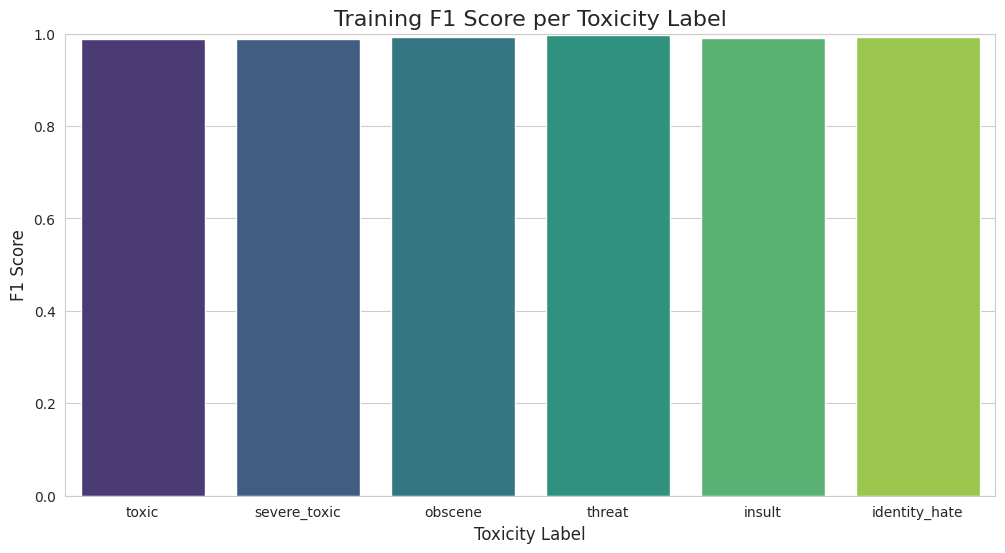

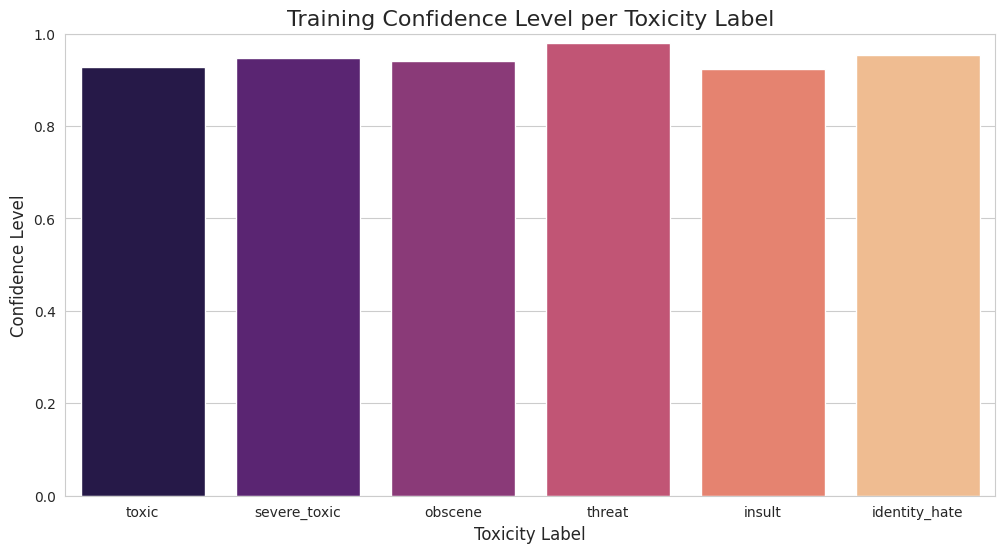

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the data is numeric for plotting
results_df_train['F1 Score'] = results_df_train['F1 Score'].astype(float)
results_df_train['Confidence'] = results_df_train['Confidence'].astype(float)

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(x='Label', y='F1 Score', data=results_df_train, palette='viridis')
plt.title('Training F1 Score per Toxicity Label', fontsize=16)
plt.xlabel('Toxicity Label', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Label', y='Confidence', data=results_df_train, palette='magma')
plt.title('Training Confidence Level per Toxicity Label', fontsize=16)
plt.xlabel('Toxicity Label', fontsize=12)
plt.ylabel('Confidence Level', fontsize=12)
plt.ylim(0, 1)
plt.show()

## **Cell 9 - Evaluating the Model**

# Cell 9: Evaluate the Ensemble Model on the Testing Dataset

## Objective
Evaluate the performance of the trained ensemble model using the unseen testing dataset.

## Purpose
This step measures how well the trained model generalizes to new, unseen data by computing class-wise and overall evaluation metrics such as Accuracy, Precision, Recall, F1-Score, Confidence Level, and Inference Time.

## Expected Output
- Predictions for every testing sample.
- Class-wise evaluation metrics for all toxicity labels.
- Overall Accuracy, Precision, Recall, and F1-Score.
- Average Confidence Level.
- Total Inference Time and Time per Sample.

## Why is this step required?
Testing on unseen data is the most important evaluation stage because it indicates how well the model is expected to perform in real-world scenarios. Comparing training and testing metrics also helps determine whether the model is overfitting or generalizing effectively.

In [11]:
# Start Measuring Inference Time


# Record the current time before making predictions.
# This helps calculate how long the model takes to make predictions.

start = time.time()
y_pred = multi_ensemble.predict(X_test_tfidf)
y_pred_proba = np.array([
    est.predict_proba(X_test_tfidf)
    for est in multi_ensemble.estimators_
])
end = time.time()
inference_time = end - start

# Display Evaluation Header
print("=" * 75)
print(f"{'ENSEMBLE MODEL EVALUATION':^75}")
print("=" * 75)

# Calculate Class-wise Evaluation Metrics
# Create an empty list to store the evaluation results.
results = []


# Loop through every toxicity label.
for i, label in enumerate(label_cols):
    acc = accuracy_score(y_test[:, i], y_pred[:, i])
    prec = precision_score(y_test[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_test[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)

    # Calculate Confidence Score

    # Retrieve prediction probabilities
    # for the current toxicity label.

    label_proba = y_pred_proba[i]
    if label_proba.shape[1] == 2:
        max_probas = np.max(label_proba, axis=1)
    else:
        max_probas = label_proba[:, 0]
    confidence = np.mean(max_probas)

    results.append({
        'Label': label,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1 Score': f"{f1:.4f}",
        'Confidence': f"{confidence:.4f}"
    })

# Display Class-wise Evaluation Table
# Convert the evaluation results into a DataFrame.
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))



# Calculate Overall Evaluation Metrics

avg_acc = accuracy_score(y_test, y_pred)
avg_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
avg_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
avg_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Calculate Overall Confidence Level

# Create an empty list to store confidence values.
all_max_probas = []
for i in range(len(label_cols)):
    label_proba = y_pred_proba[i]
    if label_proba.shape[1] == 2:
        all_max_probas.extend(np.max(label_proba, axis=1).tolist())
    else:
        all_max_probas.extend(label_proba[:, 0].tolist())
overall_confidence = np.mean(all_max_probas)

# Display Overall Evaluation Metrics

print("\n" + "=" * 75)
print(f"{'OVERALL AVERAGES':^75}")
print("=" * 75)
print(f"  Accuracy         : {avg_acc:.4f}  ({avg_acc*100:.2f}%)")
print(f"  Precision (macro): {avg_prec:.4f}  ({avg_prec*100:.2f}%)")
print(f"  Recall (macro)   : {avg_rec:.4f}  ({avg_rec*100:.2f}%)")
print(f"  F1 Score (macro) : {avg_f1:.4f}  ({avg_f1*100:.2f}%)")
print(f"  Confidence Level : {overall_confidence:.4f}  ({overall_confidence*100:.2f}%)")
print(f"\n  Inference Time   : {inference_time:.4f}s")
print(f"  Samples Tested   : {len(y_test)}")
print(f"  Time per Sample  : {(inference_time/len(y_test)*1000):.4f} ms")
print("=" * 75)

                         ENSEMBLE MODEL EVALUATION                         
        Label Accuracy Precision Recall F1 Score Confidence
        toxic   0.9575    0.9869 0.9432   0.9646     0.9106
 severe_toxic   0.9915    0.9623 0.9992   0.9804     0.9436
      obscene   0.9811    0.9814 0.9788   0.9801     0.9282
       threat   0.9984    0.9896 1.0000   0.9948     0.9783
       insult   0.9721    0.9671 0.9738   0.9704     0.9089
identity_hate   0.9956    0.9795 0.9998   0.9895     0.9509

                             OVERALL AVERAGES                              
  Accuracy         : 0.9151  (91.51%)
  Precision (macro): 0.9778  (97.78%)
  Recall (macro)   : 0.9825  (98.25%)
  F1 Score (macro) : 0.9800  (98.00%)
  Confidence Level : 0.9368  (93.68%)

  Inference Time   : 25.3182s
  Samples Tested   : 22579
  Time per Sample  : 1.1213 ms


## 9.1 Evaluate the Model on Testing Data in Graph

#  Visualizing Ensemble Model Performance

## **Objective**
To visualize the testing performance of the Ensemble Model using graphical representations of the **F1 Score** and **Confidence Level** for each toxicity category.

---

## **Purpose**
- Compare the model's performance across all toxicity labels.
- Identify which labels have higher or lower prediction performance.
- Evaluate the confidence of the model for each toxicity category.
- Present evaluation results in an easy-to-understand visual format.

---

## **Expected Output**
- A bar chart displaying the **F1 Score** for each toxicity label.
- A bar chart displaying the **Confidence Level** for each toxicity label.

---

## **Why this Step is Required**
Visualizing evaluation metrics makes it easier to analyze the strengths and weaknesses of the model. Instead of reading numerical values from a table, graphs provide a quick comparison of performance across all toxicity categories.

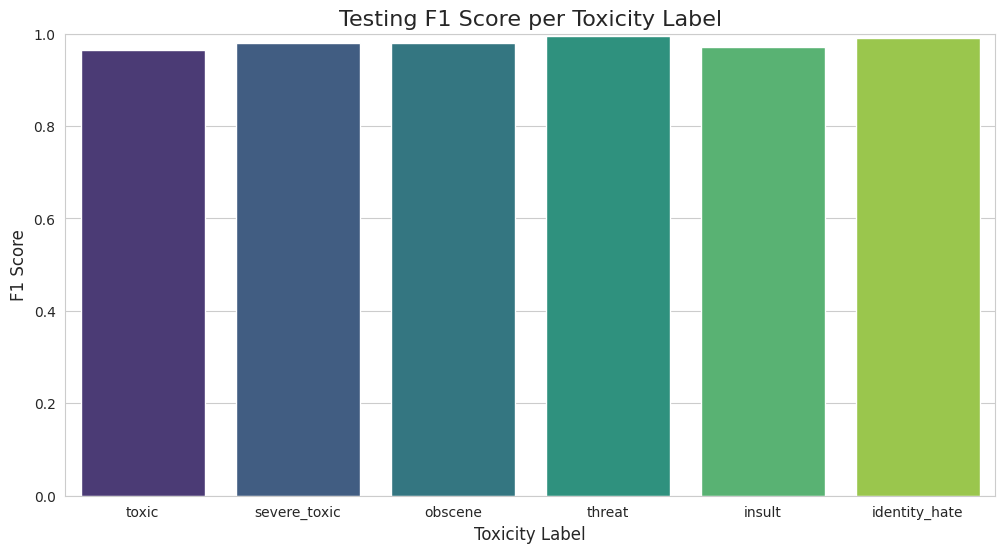

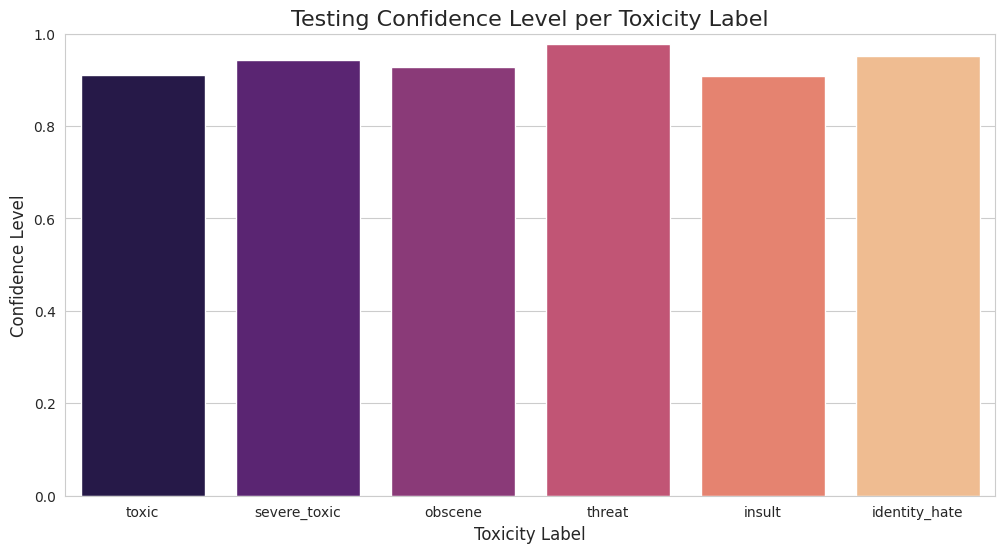

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the data is numeric for plotting
results_df['F1 Score'] = results_df['F1 Score'].astype(float)
results_df['Confidence'] = results_df['Confidence'].astype(float)

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(x='Label', y='F1 Score', data=results_df, palette='viridis')
plt.title('Testing F1 Score per Toxicity Label', fontsize=16)
plt.xlabel('Toxicity Label', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Label', y='Confidence', data=results_df, palette='magma')
plt.title('Testing Confidence Level per Toxicity Label', fontsize=16)
plt.xlabel('Toxicity Label', fontsize=12)
plt.ylabel('Confidence Level', fontsize=12)
plt.ylim(0, 1)
plt.show()

## **Cell 10 - Model Testing**

# Cell 10: Test the Trained Ensemble Model on Sample Comments

## Objective
Evaluate the trained ensemble model by predicting the toxicity categories of new user comments.

## Purpose
This step demonstrates how the trained model can classify unseen comments. Each input comment is preprocessed, converted into TF-IDF features, and passed through the ensemble classifier to obtain toxicity probabilities for all six labels.

## Expected Output
- The original input comment.
- The cleaned version of the comment after preprocessing.
- The predicted probability for each toxicity category.
- A visual confidence bar for each label.
- A HIGH or LOW toxicity flag based on a 50% confidence threshold.

## Why is this step required?
After training the model, it is important to verify its performance on new comments. This testing step simulates real-world usage by showing how the model processes user input, predicts toxicity scores, and identifies potentially harmful content before deployment.

In [12]:
# Define a function that predicts toxicity labels for a given input comment.
# This function performs preprocessing, feature extraction,
# probability prediction, and displays the prediction results.

def predict_ensemble(text):
    cleaned = tp.process_text(text)
    vectorized = tfidf.transform([cleaned])

    probas = []
    for model in multi_ensemble.estimators_:
        proba = model.predict_proba(vectorized)

        # handle binary vs single output
        if proba.shape[1] == 2:
            probas.append(float(proba[0][1]))
        else:
            probas.append(float(proba[0][0]))

    results = {}
    for label, prob in zip(label_cols, probas):
        results[label] = round(prob * 100, 2)


      # Display Prediction Results

    print("\n" + "=" * 55)
    print(f"Input   : {text}")
    print(f"Cleaned : {cleaned}")

    print("\n--- Ensemble Results ---")
    for label, score in results.items():
        flag = "HIGH" if score > 50 else "LOW"
        bar = "█" * int(score / 5)
        print(f"{label:15s}: {score:6.2f}% {bar} {flag}")

    print("=" * 55)

    return results


# Test the Ensemble Model

# Create a list of sample comments.
# These examples include toxic, threatening,
# identity hate, offensive, and non-toxic comments.
test_inputs = [
    "You are such an idiot",
    "I will kill you",
    "I h4te your kind",
    "y0u @re so stuuupid",
    "I love you baby",
    "I nearly died laughing",
    "Thanks for your help today!",
    "Good morning everyone!",
    "You"
]

# Loop through every sample comment.
for text in test_inputs:

  # Call the prediction function for each comment.
    # The prediction results are displayed in the console.
    predict_ensemble(text)


Input   : You are such an idiot
Cleaned : you are such an idiot

--- Ensemble Results ---
toxic          : 100.00% ████████████████████ HIGH
severe_toxic   :   2.86%  LOW
obscene        :  50.24% ██████████ HIGH
threat         :   0.40%  LOW
insult         : 100.00% ████████████████████ HIGH
identity_hate  :   2.74%  LOW

Input   : I will kill you
Cleaned : i will kill you

--- Ensemble Results ---
toxic          : 100.00% ████████████████████ HIGH
severe_toxic   :  11.92% ██ LOW
obscene        :  20.69% ████ LOW
threat         :  55.00% ███████████ HIGH
insult         :  25.08% █████ LOW
identity_hate  :   2.21%  LOW

Input   : I h4te your kind
Cleaned : i hate your kind

--- Ensemble Results ---
toxic          :  91.74% ██████████████████ HIGH
severe_toxic   :   6.53% █ LOW
obscene        :  12.39% ██ LOW
threat         :   8.74% █ LOW
insult         :  28.07% █████ LOW
identity_hate  :  25.59% █████ LOW

Input   : y0u @re so stuuupid
Cleaned : you are so stupid

--- Ensemble Result

# Cell 11: Save the Trained Model and Create a Downloadable Archive

## Objective
Save the trained machine learning model, TF-IDF vectorizer, and toxicity label information to disk so they can be reused without retraining.

## Purpose
This step stores all the essential artifacts required for prediction and deployment. The saved files can later be loaded into applications such as Streamlit or Gradio without training the model again.

## Expected Output
- A directory containing the saved model files.
- Serialized `.pkl` files for the TF-IDF vectorizer, ensemble model, and label names.
- A compressed ZIP archive containing all saved artifacts.
- A message displaying the location of the generated ZIP file.

## Why is this step required?
Training a machine learning model can take significant time and computational resources. Saving the trained model and preprocessing objects allows the model to be deployed directly for inference without repeating the training process.

In [17]:
# Import the os module.
# This module is used for interacting with the operating system,
# such as creating folders and managing file paths.

import os

# Import the pickle module.
# Pickle is used to serialize (save) Python objects such as
# trained machine learning models and vectorizers.
import pickle

# Import the shutil module.
# This module provides file operations such as copying,
# moving, and compressing directories into ZIP files.
import shutil

# Import the joblib library.
# Joblib is optimized for saving large NumPy arrays and scikit-learn models efficiently.
import joblib

# Save TF-IDF vectorizer, ensemble model, and label columns
os.makedirs('/kaggle/working/models', exist_ok=True)

# Save TF-IDF vectorizer using joblib
joblib.dump(tfidf, '/kaggle/working/models/tfidf_vectorizer.pkl')

# Save ensemble model using joblib
joblib.dump(multi_ensemble, '/kaggle/working/models/ensemble_model.pkl')

# Save label columns using pickle
with open('/kaggle/working/models/label_cols.pkl', 'wb') as f:
    pickle.dump(label_cols, f)

# Zip the models folder
shutil.make_archive('/kaggle/working/ensemble_models', 'zip', '/kaggle/working/models')

print(f"Downloadable zip path: /kaggle/working/ensemble_models.zip")

Downloadable zip path: /kaggle/working/ensemble_models.zip


# Cell 12: Save the Trained Model Using Joblib

## Objective
Save the trained TF-IDF vectorizer and ensemble machine learning model using the Joblib library.

## Purpose
This step stores the trained model artifacts in `.pkl` format so they can be loaded later for prediction without retraining the model. Joblib is optimized for saving large NumPy arrays and scikit-learn models efficiently.

## Expected Output
- `tfidf_vectorizer.pkl` containing the trained TF-IDF vectorizer.
- `ensemble_model.pkl` containing the trained ensemble classifier.

## Why is this step required?
Training a machine learning model can take a significant amount of time. Saving the trained artifacts allows them to be reused in deployment applications such as Streamlit, Gradio, or Flask without repeating the training process. Joblib is the recommended serialization library for scikit-learn models because it is faster and more memory-efficient than Pickle for large objects.

In [18]:
# Import the Joblib library.
# Joblib is commonly used to save and load trained
# scikit-learn models efficiently.
import joblib

# Save the TF-IDF Vectorizer

# Save the trained TF-IDF vectorizer to a file.
# This preserves the learned vocabulary and feature mapping,
# ensuring that future input text is transformed in the same
# way as during model training.
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save the Ensemble Model

# Save the trained MultiOutput Ensemble model to a file.
# This allows the model to be loaded later for inference
# without retraining.
joblib.dump(multi_ensemble, "ensemble_model.pkl")

['ensemble_model.pkl']

# Cell 13: Build the Gradio User Interface for Toxicity Moderation

## Objective
Create an interactive web application using Gradio that allows users to enter a chat message and receive toxicity predictions, severity scores, and recommended moderation actions.

## Purpose
This step integrates the trained ensemble model into a user-friendly graphical interface. It enables real-time toxicity detection without requiring users to interact directly with the Python code.

## Expected Output
- A Gradio web application.
- A text box where users can enter a message.
- A prediction output showing:
  - Detected toxicity labels
  - Severity score
  - Recommended moderation action
- Clear and Submit buttons.
- A customized interface with improved styling.

## Why is this step required?
Machine learning models are more useful when integrated into interactive applications. Gradio provides a simple way to deploy the trained model as a web application, allowing users to test comments and view toxicity predictions in real time.

In [19]:
import gradio as gr

# This function now uses your trained ensemble model for prediction
def predict(text):
    # Call the actual ensemble prediction function (defined in a previous cell)
    raw_results_percent = predict_ensemble(text) # This function returns a dictionary of label:score (0-100)

    detected_labels = []
    for label, score in raw_results_percent.items():
        # Use a threshold (e.g., 50%) to consider a label as 'detected'
        if score > 50.0:
            detected_labels.append(label)

    if not detected_labels:
        labels_str = "non-toxic"
        severity = 1
        action = "Allow"
    else:
        labels_str = ", ".join(detected_labels)
        # Determine severity based on the number of detected toxic labels
        # Capping at 5 for a scale of 1-5, where 1 is non-toxic.
        severity = min(len(detected_labels) + 1, 5)

        # Assign action based on severity
        if severity == 1:
            action = "Allow" # This case should ideally not be reached if detected_labels is not empty
        elif severity == 2:
            action = "Warning"
        elif severity == 3:
            action = "Mute"
        elif severity == 4:
            action = "Temporary Ban"
        else: # severity == 5
            action = "Auto Ban"

    return (
        labels_str,
        severity,
        action
    )


# -----------------------------
# Interface Function
# -----------------------------
def moderate(message):

    labels, severity, action = predict(message)

    result = f"""
### Output

**Message:** {message}

**Detected Labels:** {labels}

**Severity Score:** {severity}

**Recommended Action:** {action}
"""

    return result


# -----------------------------
# Custom Theme
# -----------------------------
css = """
body{
    background:#0f1117;
}

.gradio-container{
    max_width:1000px !important;
}

textarea{
    font_size:16px !important;
}

.output-box{
    background:#1b1d24;
}

footer{
    display:none;
}
"""


# -----------------------------
# UI
# -----------------------------
with gr.Blocks(css=css, theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        """
        # ❤  Toxicity Moderation App

        Enter a message to get its toxicity prediction,
        severity score and recommended moderation action.
        """
    )

    with gr.Row():

        message = gr.Textbox(
            label="Message",
            lines=8,
            placeholder="Type a comment..."
        )

        output = gr.Markdown(label="Output")

    with gr.Row():

        clear = gr.ClearButton(
            components=[message, output],
            value="Clear"
        )

        analyze = gr.Button(
            "Submit", # Changed from "Flag" to "Submit"
            variant="primary"
        )

    analyze.click(
        moderate,
        inputs=message,
        outputs=output
    )


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6edf48d9a33ce81f3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
